# Expected Number of Bets (ENB) Bootstrap Analysis

This notebook loads the time series data, trims it to the 2020-2025 period, drops funds without a full track record, and performs a bootstrap analysis of the Expected Number of Bets (ENB) using PCA.

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
import random

sns.set_theme()

In [16]:
# Load the data
df = pd.read_csv('data/time_series_jpm_renamed.csv', index_col='date', parse_dates=True)

# Trim the data to span from 2020 to the end of 2025
df_trimmed = df.loc['2020-01-01':'2025-12-31']

# Drop funds that do not have a full track record in this period
# A full track record means no missing values
df_clean = df_trimmed.dropna(axis=1, how='any')

# In some datasets, missing data is padded with exactly 0.0.
# Let's filter out funds that have 0.0 return for more than 10% of the time,
# as these likely don't have a true full track record.
zero_counts = (df_clean == 0.0).sum(axis=0)
valid_funds = zero_counts[zero_counts < (len(df_clean) * 0.1)].index
df_clean = df_clean[valid_funds]

print(f"Original number of funds: {df.shape[1]}")
print(f"Number of funds after trimming and dropping incomplete track records: {df_clean.shape[1]}")

Original number of funds: 943
Number of funds after trimming and dropping incomplete track records: 347


In [17]:
def compute_enb(returns):
    # Compute correlation matrix
    corr_matrix = returns.corr().fillna(0)
    
    # Compute eigenvalues using numpy
    eigenvalues = np.linalg.eigvals(corr_matrix)
    
    # Sort eigenvalues descending and ensure they are real
    eigenvalues = np.real(eigenvalues)
    eigenvalues = np.sort(eigenvalues)[::-1]
    
    # Keep only positive eigenvalues to avoid numerical issues
    eigenvalues = eigenvalues[eigenvalues > 1e-8]
    
    # Expected Number of Bets (ENB)
    # ENB = (sum(lambda))^2 / sum(lambda^2)
    if len(eigenvalues) == 0:
        return 1.0
        
    enb = (np.sum(eigenvalues) ** 2) / np.sum(eigenvalues ** 2)
    return enb

In [18]:
# Bootstrap to compute ENB distribution
n_iterations = 30000
enb_values = []

np.random.seed(42)
random.seed(42)

funds_list = df_clean.columns.tolist()

for _ in range(n_iterations):
    # Pick 10 to 15 funds randomly
    n_funds = 14
    selected_funds = random.sample(funds_list, n_funds)
    
    # Subset returns
    returns_subset = df_clean[selected_funds]
    
    # Compute ENB
    enb = compute_enb(returns_subset)
    enb_values.append(enb)

enb_series = pd.Series(enb_values)

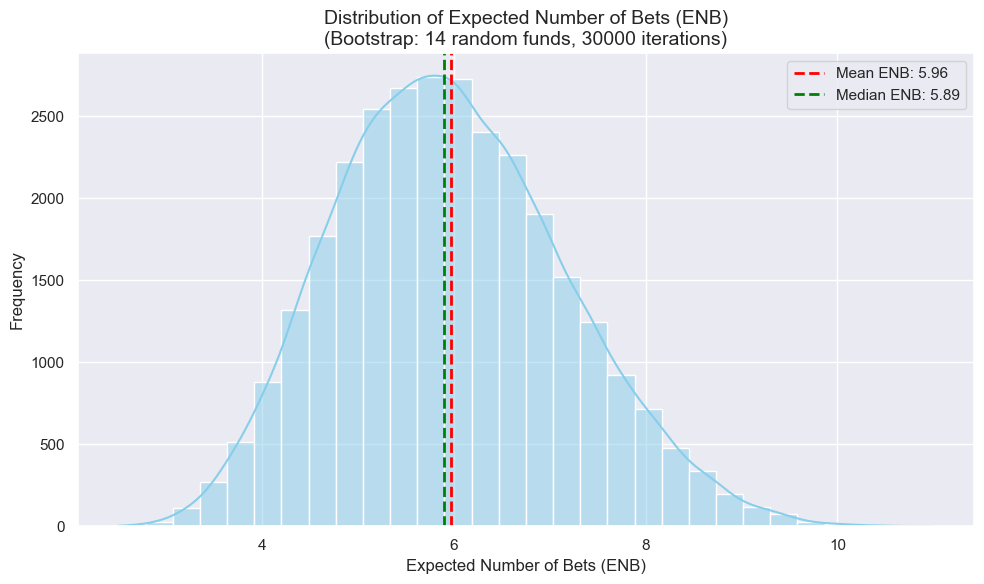

In [19]:
# Plot the distribution of ENB
plt.figure(figsize=(10, 6))
sns.histplot(enb_series, bins=30, kde=True, color='skyblue')
plt.axvline(enb_series.mean(), color='red', linestyle='dashed', linewidth=2, label=f'Mean ENB: {enb_series.mean():.2f}')
plt.axvline(enb_series.median(), color='green', linestyle='dashed', linewidth=2, label=f'Median ENB: {enb_series.median():.2f}')
plt.title(f'Distribution of Expected Number of Bets (ENB)\n(Bootstrap: {n_funds} random funds, {n_iterations} iterations)', fontsize=14)
plt.xlabel('Expected Number of Bets (ENB)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()